# Experiment 2.1.1 — What temporal information makes the FF SNN work?

## Research question

Experiment 2.1 showed that `timestep_ce` and `relative_10bin_ce` are the two useful objectives. This notebook narrows the question to:

\[
\boxed{\text{What temporal information is responsible for their classification performance?}}
\]

Only two objectives are trained:

1. **`timestep_ce`** — masked CE at every valid timestep; native inference is full-segment output-spike count.
2. **`relative_10bin_ce`** — ten relative-progress output-spike-count bins followed by a trainable linear readout.

### Changes from Experiment 2.1

- Train only the two objectives above.
- Use the same 5 paired master seeds and the same user-disjoint split.
- Train the full fixed epoch budget; **no early stopping**.
- Select and restore the checkpoint with **highest validation Balanced Accuracy**. Ties are broken by lower validation loss, then earlier epoch.
- Save each completed `seed × objective` checkpoint/history immediately so the notebook can be stopped and resumed.

## Diagnostic A — where does `timestep_ce` evidence live?

For the trained `timestep_ce` model, divide each **unmodified** test segment into 10 relative-progress bins. For each bin independently, count output spikes and classify with `argmax`:

\[
BA_1, BA_2, \ldots, BA_{10}
\]

Compare them with the ordinary full-segment count classifier:

\[
BA_{full}
\]

Interpretation:

- strong per-bin BA + stronger full BA → local class evidence exists and full count behaves like evidence accumulation / voting;
- chance-like per-bin BA + strong full BA → many weak local cues accumulate across the whole segment.

Silent-bin fraction is reported because an all-zero output bin produces an arbitrary `argmax` tie and must not be mistaken for useful evidence.

## Diagnostic B — input temporal-order ablation

At **test time only**, shuffle the order of valid contiguous input blocks while leaving every block internally unchanged. Padding never participates.

- **200 ms blocks**: tests sensitivity to fairly local order;
- **500 ms blocks**: tests longer-range order.

The model state is reset normally at the beginning of every shuffled segment. Each shuffle repeat uses deterministic sample-specific permutations.

If `timestep_ce` keeps nearly the same BA after 500 ms block shuffling, the current feed-forward SNN is behaving mainly like a **bag-of-local-motifs / evidence accumulator**. A large BA drop means the intrinsic Synaptic-LIF dynamics and boundary transitions make the classifier order-sensitive even without recurrent weights.

## Diagnostic C — `relative_10bin_ce` readout-order ablation

For `relative_10bin_ce`, additionally keep the SNN output sequence fixed and permute only the ten relative-bin feature slots before the trained linear head. This is a cheap direct test of whether the readout depends on **which temporal phase** produced the spikes rather than only on the multiset of bin counts.


In [1]:
from __future__ import annotations

from pathlib import Path
import copy, hashlib, json, math, os, random, sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from IPython.display import display

import snntorch as snn
from snntorch import surrogate
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the writingRing repository root")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print("Repository root:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Repository root: /home/ted/project/writingring-viz
PyTorch: 2.11.0+cu130
CUDA available: True


## 1. Configuration

The default epoch budget is 150 to match the completed Experiment 2.1 run shown in the training logs. Reduce it only for debugging.


In [3]:
DATASET_ROOTS = [
    REPO_ROOT / "outputs/action0_wavelets_1_2_4_8_16",
    REPO_ROOT / "outputs/action1_wavelets_1_2_4_8_16",
]

INCLUDED_LABELS = (
    "A", "B", "C", "D", "E", "X",
    "G", "H", "I", "J", "K", "L",
)

SPLIT_SEED = 12345
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15

SEEDS = (11, 23)#, 101, 40, 231
OBJECTIVES_TO_RUN = (
    "timestep_ce",
    "relative_10bin_ce",
)

BATCH_SIZE = 128
NUM_WORKERS = 0

# Fixed compute budget. No early stopping.
NUM_EPOCHS = 120
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.0
GRAD_CLIP_NORM = None

FIRING_ONSET_THRESHOLD = 1e-3

HIDDEN_WIDTH = 64
N_RELATIVE_BINS = 10

TAU_SYN_MS = 77.47
TAU_MEM_MS = 7.213
THRESHOLD = 1.0
SURROGATE_SLOPE = 25.0
RESET_MECHANISM = "subtract"

SPIKE_REGULARIZATION = 0.0
ZERO_INPUT_DIAGNOSTIC_STEPS = 200

# Test-time order ablations.
SHUFFLE_BLOCK_MS = (200.0, 500.0)
N_SHUFFLE_REPEATS = 5
N_READOUT_BIN_SHUFFLE_REPEATS = 20  # cheap: no extra backbone forward passes

# Persist every completed run. Set True after an interruption to load saved checkpoints.
RESUME_EXISTING = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EXPERIMENT_ID = "experiment_2_1_1_timestep_relative10bin_temporal_order"
RESULTS_DIR = (
    REPO_ROOT
    / "notebooks/artifacts/experiment_2_1_1_timestep_relative10bin_temporal_order"
)
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"
HISTORY_DIR = RESULTS_DIR / "histories"

print("Objectives:", OBJECTIVES_TO_RUN)
print("Seeds:", SEEDS)
print("Full SNN trainings:", len(OBJECTIVES_TO_RUN) * len(SEEDS))
print("Epoch budget:", NUM_EPOCHS)
print("Device:", DEVICE)
print("Resume existing:", RESUME_EXISTING)


Objectives: ('timestep_ce', 'relative_10bin_ce')
Seeds: (11, 23)
Full SNN trainings: 4
Epoch budget: 120
Device: cuda
Resume existing: True


## 2. Reproducibility

In [4]:
def derive_seed(master_seed: int, *parts: object) -> int:
    text = "|".join([str(master_seed), *(str(p) for p in parts)])
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


def worker_init_fn(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)


## 3. Load and validate unsigned dynamic-channel event data

In [5]:
data = load_acceleration_data(
    DATASET_ROOTS,
    repository_root=REPO_ROOT,
    require_reconstruction=False,
)

sampling_rates = {float(m.sampling_rate_hz) for m in data.producer_metadatas}
if len(sampling_rates) != 1:
    raise ValueError(f"Expected one shared sampling rate, got {sampling_rates}")
SAMPLING_RATE_HZ = sampling_rates.pop()

event_contracts = set()
for metadata in data.producer_metadatas:
    raw = metadata.raw
    event_representation = raw.get("event_representation")
    event_feature_schema = raw.get("event_feature_schema")
    event_channel_count = raw.get("event_channel_count")
    encoder_spec_sha256 = raw.get("spike_encoder_spec_sha256")

    if event_representation != "unsigned":
        raise ValueError(
            "Requires event_representation='unsigned'; "
            f"got {event_representation!r}"
        )
    if not isinstance(event_feature_schema, str) or not event_feature_schema:
        raise ValueError("Missing event_feature_schema")
    if not isinstance(event_channel_count, int) or event_channel_count <= 0:
        raise ValueError("event_channel_count must be positive")
    if event_channel_count != metadata.channel_count - 6:
        raise ValueError(
            "Expected six auxiliary IMU channels after event channels; "
            f"event={event_channel_count}, total={metadata.channel_count}"
        )
    if not isinstance(encoder_spec_sha256, str) or len(encoder_spec_sha256) != 64:
        raise ValueError("Missing spike_encoder_spec_sha256")

    event_contracts.add(
        (
            event_representation,
            event_feature_schema,
            event_channel_count,
            encoder_spec_sha256,
        )
    )

if len(event_contracts) != 1:
    raise ValueError(f"Incompatible event contracts: {event_contracts}")

(
    EVENT_REPRESENTATION,
    EVENT_FEATURE_SCHEMA,
    INPUT_CHANNELS,
    ENCODER_SPEC_SHA256,
) = event_contracts.pop()

rows = []
included = None if INCLUDED_LABELS is None else set(map(str, INCLUDED_LABELS))
padded_lengths = set()

for package_index, package in enumerate(data.packages):
    padded_lengths.add(int(package.padded_spike_imu.shape[1]))

    for segment_index, label in enumerate(package.labels.astype(str)):
        label = str(label)
        if included is not None and label not in included:
            continue

        valid_length = int(package.valid_lengths[segment_index])
        if valid_length <= 0:
            raise ValueError("valid_length must be positive")

        event_values = np.asarray(
            package.padded_spike_imu[
                segment_index, :valid_length, :INPUT_CHANNELS
            ]
        )
        if np.any(~np.isfinite(event_values)):
            raise ValueError("Non-finite event values")
        if np.any(event_values < 0.0):
            raise ValueError(
                f"Unsigned event contract violated for "
                f"{package.user}/action_{package.action}/{segment_index}"
            )

        rows.append(
            {
                "package_index": package_index,
                "segment_index": segment_index,
                "user": str(package.user),
                "action": str(package.action),
                "label": label,
                "valid_length": valid_length,
                "sample_id": f"{package.user}/action_{package.action}/{segment_index}",
            }
        )

if len(padded_lengths) != 1:
    raise ValueError(f"Expected one padded length, got {padded_lengths}")
PADDED_LENGTH = padded_lengths.pop()

manifest = pd.DataFrame(rows)
if manifest.empty:
    raise ValueError("No samples remain after label filtering")

labels_sorted = sorted(manifest["label"].unique().tolist())
CLASS_TO_IDX = {label: i for i, label in enumerate(labels_sorted)}
manifest["label_idx"] = manifest["label"].map(CLASS_TO_IDX).astype(int)
NUM_CLASSES = len(CLASS_TO_IDX)

DT_MS = 1000.0 / SAMPLING_RATE_HZ
ALPHA = float(math.exp(-DT_MS / TAU_SYN_MS))
BETA = float(math.exp(-DT_MS / TAU_MEM_MS))

print(f"alpha={ALPHA:.6f}, beta={BETA:.6f}, threshold={THRESHOLD}")


alpha=0.937498, beta=0.499977, threshold=1.0


## 4. One fixed user-disjoint split

In [6]:
def make_user_split(manifest: pd.DataFrame) -> pd.DataFrame:
    users = sorted(manifest["user"].unique().tolist())
    rng = np.random.default_rng(SPLIT_SEED)
    perm = np.array(users, dtype=object)
    rng.shuffle(perm)

    n = len(perm)
    n_train = max(1, int(np.floor(TRAIN_FRACTION * n)))
    n_val = max(1, int(np.floor(VAL_FRACTION * n)))
    if n_train + n_val >= n:
        n_train, n_val = n - 2, 1

    train_users = set(perm[:n_train].tolist())
    val_users = set(perm[n_train:n_train + n_val].tolist())

    out = manifest.copy()
    out["split"] = out["user"].map(
        lambda u: "train" if u in train_users else (
            "val" if u in val_users else "test"
        )
    )
    return out


FIXED_SPLIT_MANIFEST = make_user_split(manifest)

display(
    FIXED_SPLIT_MANIFEST.groupby("split").agg(
        users=("user", "nunique"),
        samples=("label", "size"),
        classes_present=("label", "nunique"),
    )
)


,users,samples,classes_present
split,,,
test,3,167,12
train,14,619,12
val,3,125,12


## 5. Dataset and paired DataLoaders

In [7]:
class EventSNNDataset(Dataset):
    def __init__(self, data, subset_manifest: pd.DataFrame):
        self.data = data
        self.df = subset_manifest.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        package = self.data.packages[int(row.package_index)]
        segment_index = int(row.segment_index)
        valid_length = int(row.valid_length)

        x = np.asarray(
            package.padded_spike_imu[
                segment_index, :, :INPUT_CHANNELS
            ],
            dtype=np.float32,
        ).copy()

        if x.shape != (PADDED_LENGTH, INPUT_CHANNELS):
            raise ValueError(f"Unexpected input shape {x.shape}")
        if np.any(x[:valid_length] < 0.0):
            raise ValueError("Unsigned event contract violated")

        x[valid_length:] = 0.0
        valid_mask = np.arange(PADDED_LENGTH) < valid_length

        return {
            "x": torch.from_numpy(x),
            "label": torch.tensor(int(row.label_idx), dtype=torch.long),
            "valid_mask": torch.from_numpy(valid_mask),
            "valid_length": torch.tensor(valid_length, dtype=torch.long),
            "sample_id": str(row.sample_id),
        }


def make_loader(
    subset_manifest: pd.DataFrame,
    *,
    batch_size: int,
    shuffle: bool,
    seed: int,
):
    dataset = EventSNNDataset(data, subset_manifest)
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        generator=generator,
        worker_init_fn=worker_init_fn if NUM_WORKERS > 0 else None,
        pin_memory=torch.cuda.is_available(),
    )


In [8]:
def make_split_loaders(master_seed: int):
    loaders = {}

    for name, split_name, shuffle in (
        ("train", "train", True),
        ("train_eval", "train", False),
        ("val", "val", False),
        ("test", "test", False),
    ):
        subset = FIXED_SPLIT_MANIFEST[
            FIXED_SPLIT_MANIFEST.split == split_name
        ]

        loaders[name] = make_loader(
            subset,
            batch_size=BATCH_SIZE,
            shuffle=shuffle,
            seed=derive_seed(master_seed, name, "loader"),
        )

    return loaders


## 6. Temporal aggregation helpers

Only relative 10-bin aggregation is needed for training. The same helper is reused for the timestep-CE binwise diagnostic.


In [9]:
def relative_temporal_bin_counts(
    output_spikes: torch.Tensor,
    valid_lengths: torch.Tensor,
    n_bins: int,
) -> torch.Tensor:
    """Return [B, n_bins, K] output-spike counts over relative progress."""
    _, time_steps, _ = output_spikes.shape
    lengths = valid_lengths.to(output_spikes.device, dtype=torch.long).clamp_min(1)

    t = torch.arange(time_steps, device=output_spikes.device)[None, :]
    valid = t < lengths[:, None]

    bin_index = torch.div(
        t * n_bins,
        lengths[:, None],
        rounding_mode="floor",
    ).clamp_max(n_bins - 1)

    one_hot = F.one_hot(bin_index, num_classes=n_bins).to(output_spikes.dtype)
    one_hot = one_hot * valid.unsqueeze(-1).to(output_spikes.dtype)

    return torch.einsum("btn,btk->bnk", one_hot, output_spikes)


## 7. Fixed no-bias SNN

In [10]:
class SharedBackboneSNN(nn.Module):
    def __init__(self, num_classes: int, input_channels: int):
        super().__init__()

        self.num_classes = int(num_classes)
        self.input_channels = int(input_channels)

        spike_grad = surrogate.fast_sigmoid(slope=SURROGATE_SLOPE)

        self.fc1 = nn.Linear(input_channels, HIDDEN_WIDTH, bias=False)
        self.lif1 = snn.Synaptic(
            alpha=ALPHA,
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

        self.fc2 = nn.Linear(HIDDEN_WIDTH, HIDDEN_WIDTH, bias=False)
        self.lif2 = snn.Synaptic(
            alpha=ALPHA,
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

        self.fc_out = nn.Linear(HIDDEN_WIDTH, num_classes, bias=False)
        self.lif_out = snn.Synaptic(
            alpha=ALPHA,
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

    @property
    def backbone_parameter_count(self):
        return sum(p.numel() for p in self.parameters())

    @property
    def spike_neuron_count(self):
        return 2 * HIDDEN_WIDTH + self.num_classes

    def forward(self, x, valid_mask):
        self.lif1.reset_mem()
        self.lif2.reset_mem()
        self.lif_out.reset_mem()

        spk1_rec, spk2_rec, spk_out_rec, mem_out_rec = [], [], [], []

        for step in range(x.shape[1]):
            spk1, _, _ = self.lif1(self.fc1(x[:, step, :]))
            spk2, _, _ = self.lif2(self.fc2(spk1))
            spk_out, _, mem_out = self.lif_out(self.fc_out(spk2))

            spk1_rec.append(spk1)
            spk2_rec.append(spk2)
            spk_out_rec.append(spk_out)
            mem_out_rec.append(mem_out)

        spk1_rec = torch.stack(spk1_rec, dim=1)
        spk2_rec = torch.stack(spk2_rec, dim=1)
        spk_out_rec = torch.stack(spk_out_rec, dim=1)
        mem_out_rec = torch.stack(mem_out_rec, dim=1)

        mask_f = valid_mask.unsqueeze(-1).to(spk_out_rec.dtype)
        total_valid_spikes = (
            (spk1_rec * mask_f).sum()
            + (spk2_rec * mask_f).sum()
            + (spk_out_rec * mask_f).sum()
        )

        return {
            "spk1": spk1_rec,
            "spk2": spk2_rec,
            "output_spikes": spk_out_rec,
            "output_membrane": mem_out_rec,
            "total_valid_spikes": total_valid_spikes,
        }


## 8. Two objective implementations

The SNN backbone is identical and paired across objectives. `relative_10bin_ce` alone has an additional trainable linear temporal readout.


In [11]:
OBJECTIVE_NAMES = (
    "timestep_ce",
    "relative_10bin_ce",
)


def masked_timestep_ce(output_spikes, labels, valid_mask):
    batch_size, time_steps, class_count = output_spikes.shape
    targets = labels[:, None].expand(batch_size, time_steps)

    loss_per_step = F.cross_entropy(
        output_spikes.reshape(batch_size * time_steps, class_count),
        targets.reshape(batch_size * time_steps),
        reduction="none",
    ).reshape(batch_size, time_steps)

    mask_f = valid_mask.to(loss_per_step.dtype)
    return (loss_per_step * mask_f).sum() / mask_f.sum().clamp_min(1)


class ObjectiveSNN(nn.Module):
    def __init__(self, objective, num_classes, input_channels, master_seed):
        super().__init__()

        if objective not in OBJECTIVE_NAMES:
            raise ValueError(f"Unknown objective {objective!r}")

        self.objective = objective
        self.num_classes = int(num_classes)

        # Paired backbone initialization across objectives for a given master seed.
        seed_everything(derive_seed(master_seed, "shared_backbone_init"))
        self.backbone = SharedBackboneSNN(
            num_classes=num_classes,
            input_channels=input_channels,
        )

        self.readout_head = None
        if objective == "relative_10bin_ce":
            seed_everything(derive_seed(master_seed, objective, "head_init"))
            self.readout_head = nn.Linear(
                N_RELATIVE_BINS * num_classes,
                num_classes,
                bias=True,
            )

    @property
    def backbone_parameter_count(self):
        return self.backbone.backbone_parameter_count

    @property
    def readout_parameter_count(self):
        if self.readout_head is None:
            return 0
        return sum(p.numel() for p in self.readout_head.parameters())

    @property
    def total_parameter_count(self):
        return sum(p.numel() for p in self.parameters())

    def forward(self, x, valid_mask):
        return self.backbone(x, valid_mask)

    def full_counts(self, out, valid_mask):
        return (
            out["output_spikes"]
            * valid_mask.unsqueeze(-1).to(out["output_spikes"].dtype)
        ).sum(dim=1)

    def native_logits(self, out, valid_mask, valid_lengths):
        if self.objective == "timestep_ce":
            return self.full_counts(out, valid_mask)

        if self.objective == "relative_10bin_ce":
            bins = relative_temporal_bin_counts(
                out["output_spikes"], valid_lengths, N_RELATIVE_BINS
            )
            return self.readout_head(bins.flatten(start_dim=1))

        raise RuntimeError(self.objective)

    def training_loss(self, out, labels, valid_mask, valid_lengths):
        if self.objective == "timestep_ce":
            loss = masked_timestep_ce(
                out["output_spikes"], labels, valid_mask
            )
        elif self.objective == "relative_10bin_ce":
            loss = F.cross_entropy(
                self.native_logits(out, valid_mask, valid_lengths), labels
            )
        else:
            raise RuntimeError(self.objective)

        if SPIKE_REGULARIZATION > 0:
            valid_neuron_time = (
                valid_mask.to(out["output_spikes"].dtype).sum().clamp_min(1)
                * self.backbone.spike_neuron_count
            )
            loss = (
                loss
                + SPIKE_REGULARIZATION
                * out["total_valid_spikes"]
                / valid_neuron_time
            )

        return loss


## 9. Metrics and zero-input diagnostics


In [12]:
def classification_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_true, y_pred)
        ),
        "macro_f1": float(
            f1_score(y_true, y_pred, average="macro", zero_division=0)
        ),
    }


@torch.no_grad()
def evaluate_objective_model(model, loader):
    model.eval()

    y_true, y_pred = [], []
    total_loss = 0.0
    sample_count = 0
    valid_steps = 0
    l1_spikes = l2_spikes = output_spikes = 0.0
    silent_output_samples = 0

    for batch in loader:
        x = batch["x"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)
        mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
        lengths = batch["valid_length"].to(DEVICE, non_blocking=True)

        out = model(x, mask)
        loss = model.training_loss(out, y, mask, lengths)
        logits = model.native_logits(out, mask, lengths)
        pred = logits.argmax(dim=1)

        batch_size = len(y)
        batch_valid_steps = int(mask.sum().item())

        total_loss += float(loss.item()) * batch_size
        sample_count += batch_size
        valid_steps += batch_valid_steps

        y_true.extend(y.cpu().tolist())
        y_pred.extend(pred.cpu().tolist())

        mask_f = mask.unsqueeze(-1).to(out["output_spikes"].dtype)
        batch_l1 = (out["spk1"] * mask_f).sum(dim=(1, 2))
        batch_l2 = (out["spk2"] * mask_f).sum(dim=(1, 2))
        batch_out = (out["output_spikes"] * mask_f).sum(dim=(1, 2))

        l1_spikes += float(batch_l1.sum().item())
        l2_spikes += float(batch_l2.sum().item())
        output_spikes += float(batch_out.sum().item())
        silent_output_samples += int((batch_out == 0).sum().item())

    metrics = classification_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / max(sample_count, 1)
    metrics["l1_firing_rate"] = (
        l1_spikes / max(valid_steps * HIDDEN_WIDTH, 1)
    )
    metrics["l2_firing_rate"] = (
        l2_spikes / max(valid_steps * HIDDEN_WIDTH, 1)
    )
    metrics["output_firing_rate"] = (
        output_spikes / max(valid_steps * NUM_CLASSES, 1)
    )
    metrics["network_firing_rate"] = (
        (l1_spikes + l2_spikes + output_spikes)
        / max(valid_steps * (2 * HIDDEN_WIDTH + NUM_CLASSES), 1)
    )
    metrics["silent_output_fraction"] = (
        silent_output_samples / max(sample_count, 1)
    )
    metrics["samples"] = sample_count
    return metrics


@torch.no_grad()
def zero_input_activity(model, steps=ZERO_INPUT_DIAGNOSTIC_STEPS):
    model.eval()

    x = torch.zeros(
        1,
        steps,
        INPUT_CHANNELS,
        device=DEVICE,
    )
    mask = torch.ones(
        1,
        steps,
        dtype=torch.bool,
        device=DEVICE,
    )

    out = model(x, mask)

    return {
        "zero_l1_firing_rate": float(out["spk1"].mean().item()),
        "zero_l2_firing_rate": float(out["spk2"].mean().item()),
        "zero_output_firing_rate": float(
            out["output_spikes"].mean().item()
        ),
    }


## 10. Fixed-budget training; select best checkpoint by validation BA

Every epoch is still run. Model selection is now aligned with the primary metric: **validation Balanced Accuracy**.

Tie-breaking rule:

1. higher validation BA;
2. if BA is numerically tied, lower validation loss;
3. if both tie, keep the earlier epoch.


In [13]:
def _cpu_state_dict(model):
    return {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }


def train_one_objective(
    *,
    objective: str,
    master_seed: int,
    train_loader,
    train_eval_loader,
    val_loader,
):
    model = ObjectiveSNN(
        objective=objective,
        num_classes=NUM_CLASSES,
        input_channels=INPUT_CHANNELS,
        master_seed=master_seed,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_state = None
    best_val_ba = -np.inf
    best_val_loss = np.inf
    best_epoch = -1
    firing_onset_epoch = None
    history_rows = []

    zero_before = zero_input_activity(model)

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()

        for batch in train_loader:
            x = batch["x"].to(DEVICE, non_blocking=True)
            y = batch["label"].to(DEVICE, non_blocking=True)
            mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
            lengths = batch["valid_length"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            out = model(x, mask)
            loss = model.training_loss(out, y, mask, lengths)

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"Non-finite loss for objective={objective}, seed={master_seed}"
                )

            loss.backward()
            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()

        train_metrics = evaluate_objective_model(model, train_eval_loader)
        val_metrics = evaluate_objective_model(model, val_loader)

        if (
            firing_onset_epoch is None
            and val_metrics["output_firing_rate"] > FIRING_ONSET_THRESHOLD
        ):
            firing_onset_epoch = epoch

        val_ba = val_metrics["balanced_accuracy"]
        val_loss = val_metrics["loss"]
        improved = (
            val_ba > best_val_ba + 1e-12
            or (
                abs(val_ba - best_val_ba) <= 1e-12
                and val_loss < best_val_loss - 1e-12
            )
        )
        if improved:
            best_val_ba = val_ba
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = _cpu_state_dict(model)

        history_rows.append(
            {
                "seed": master_seed,
                "objective": objective,
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "train_balanced_accuracy": train_metrics["balanced_accuracy"],
                "train_macro_f1": train_metrics["macro_f1"],
                "train_l1_firing_rate": train_metrics["l1_firing_rate"],
                "train_l2_firing_rate": train_metrics["l2_firing_rate"],
                "train_output_firing_rate": train_metrics["output_firing_rate"],
                "train_silent_output_fraction": train_metrics["silent_output_fraction"],
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_l1_firing_rate": val_metrics["l1_firing_rate"],
                "val_l2_firing_rate": val_metrics["l2_firing_rate"],
                "val_output_firing_rate": val_metrics["output_firing_rate"],
                "val_silent_output_fraction": val_metrics["silent_output_fraction"],
            }
        )

        if epoch == 1 or epoch % 10 == 0 or epoch == NUM_EPOCHS:
            print(
                f"epoch {epoch:>3d} | "
                f"train loss={train_metrics['loss']:.4f} "
                f"train BA={train_metrics['balanced_accuracy']:.4f} | "
                f"val loss={val_metrics['loss']:.4f} "
                f"val BA={val_metrics['balanced_accuracy']:.4f} | "
                f"out FR={val_metrics['output_firing_rate']:.4f}"
            )

    if best_state is None:
        raise RuntimeError("No best checkpoint selected")

    model.load_state_dict(best_state)
    zero_after = zero_input_activity(model)

    return {
        "model": model,
        "history": pd.DataFrame(history_rows),
        "best_epoch": best_epoch,
        "best_val_ba": best_val_ba,
        "best_val_loss": best_val_loss,
        "firing_onset_epoch": firing_onset_epoch,
        "zero_before": zero_before,
        "zero_after": zero_after,
    }


## 11. Persistent checkpoints and resume support

Each completed `seed × objective` run is saved immediately. If `RESUME_EXISTING=True`, rerunning this notebook loads the saved best-val-BA checkpoint instead of retraining that run.


In [14]:
def checkpoint_path(master_seed, objective):
    return CHECKPOINT_DIR / f"seed_{master_seed}_{objective}_best_val_ba.pt"


def history_path(master_seed, objective):
    return HISTORY_DIR / f"seed_{master_seed}_{objective}_history.csv"


def save_completed_run(master_seed, objective, run):
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    HISTORY_DIR.mkdir(parents=True, exist_ok=True)

    payload = {
        "experiment_id": EXPERIMENT_ID,
        "seed": int(master_seed),
        "objective": str(objective),
        "best_epoch": int(run["best_epoch"]),
        "best_val_ba": float(run["best_val_ba"]),
        "best_val_loss": float(run["best_val_loss"]),
        "firing_onset_epoch": run["firing_onset_epoch"],
        "zero_before": run["zero_before"],
        "zero_after": run["zero_after"],
        "num_epochs": int(NUM_EPOCHS),
        "input_channels": int(INPUT_CHANNELS),
        "num_classes": int(NUM_CLASSES),
        "hidden_width": int(HIDDEN_WIDTH),
        "state_dict": _cpu_state_dict(run["model"]),
    }
    torch.save(payload, checkpoint_path(master_seed, objective))
    run["history"].to_csv(history_path(master_seed, objective), index=False)


def load_completed_run(master_seed, objective):
    ckpt = checkpoint_path(master_seed, objective)
    hist = history_path(master_seed, objective)
    if not (ckpt.exists() and hist.exists()):
        return None

    payload = torch.load(ckpt, map_location="cpu", weights_only=False)
    required = {
        "experiment_id": EXPERIMENT_ID,
        "seed": int(master_seed),
        "objective": str(objective),
        "num_epochs": int(NUM_EPOCHS),
        "input_channels": int(INPUT_CHANNELS),
        "num_classes": int(NUM_CLASSES),
        "hidden_width": int(HIDDEN_WIDTH),
    }
    for key, expected in required.items():
        if payload.get(key) != expected:
            raise ValueError(
                f"Checkpoint mismatch for {ckpt}: {key}={payload.get(key)!r}, "
                f"expected {expected!r}. Delete the stale checkpoint or change RESULTS_DIR."
            )

    model = ObjectiveSNN(
        objective=objective,
        num_classes=NUM_CLASSES,
        input_channels=INPUT_CHANNELS,
        master_seed=master_seed,
    ).to(DEVICE)
    model.load_state_dict(payload["state_dict"])

    return {
        "model": model,
        "history": pd.read_csv(hist),
        "best_epoch": int(payload["best_epoch"]),
        "best_val_ba": float(payload["best_val_ba"]),
        "best_val_loss": float(payload["best_val_loss"]),
        "firing_onset_epoch": payload.get("firing_onset_epoch"),
        "zero_before": payload.get("zero_before", {}),
        "zero_after": payload.get("zero_after", {}),
    }


## 12. Main two-objective × five-seed sweep

This cell trains or resumes the two models, evaluates the restored best-val-BA checkpoint, and writes the current result table after **every completed run**.


In [15]:
for objective in OBJECTIVES_TO_RUN:
    if objective not in OBJECTIVE_NAMES:
        raise ValueError(f"Unknown objective {objective!r}")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

result_rows = []
history_frames = []

for master_seed in SEEDS:
    print("=" * 100)
    print("MASTER SEED:", master_seed)

    for objective in OBJECTIVES_TO_RUN:
        print("-" * 100)
        print("OBJECTIVE:", objective)

        loaders = make_split_loaders(master_seed)
        run = None

        if RESUME_EXISTING:
            run = load_completed_run(master_seed, objective)
            if run is not None:
                print(
                    f"Loaded saved best-val-BA checkpoint: "
                    f"epoch={run['best_epoch']}, val BA={run['best_val_ba']:.4f}"
                )

        if run is None:
            run = train_one_objective(
                objective=objective,
                master_seed=master_seed,
                train_loader=loaders["train"],
                train_eval_loader=loaders["train_eval"],
                val_loader=loaders["val"],
            )
            save_completed_run(master_seed, objective, run)

        model = run["model"]
        history_frames.append(run["history"])

        split_metrics = {
            "train": evaluate_objective_model(model, loaders["train_eval"]),
            "val": evaluate_objective_model(model, loaders["val"]),
            "test": evaluate_objective_model(model, loaders["test"]),
        }

        row = {
            "experiment": EXPERIMENT_ID,
            "seed": master_seed,
            "objective": objective,
            "best_epoch_by_val_ba": run["best_epoch"],
            "best_val_ba": run["best_val_ba"],
            "val_loss_at_best_val_ba": run["best_val_loss"],
            "firing_onset_epoch": (
                np.nan if run["firing_onset_epoch"] is None
                else run["firing_onset_epoch"]
            ),
            "input_channels": INPUT_CHANNELS,
            "hidden_width": HIDDEN_WIDTH,
            "num_classes": NUM_CLASSES,
            "backbone_params": model.backbone_parameter_count,
            "readout_params": model.readout_parameter_count,
            "total_params": model.total_parameter_count,
            **run["zero_after"],
        }

        for split_name, metrics in split_metrics.items():
            for metric_name, value in metrics.items():
                row[f"{split_name}_{metric_name}"] = value

        result_rows.append(row)

        # Incremental save: safe to stop after any completed objective.
        results = pd.DataFrame(result_rows)
        histories = pd.concat(history_frames, ignore_index=True)
        results.to_csv(RESULTS_DIR / "experiment_2_1_1_results.csv", index=False)
        histories.to_csv(RESULTS_DIR / "experiment_2_1_1_histories.csv", index=False)

        print(
            f"best-val-BA epoch={run['best_epoch']} | "
            f"train BA={split_metrics['train']['balanced_accuracy']:.4f} | "
            f"val BA={split_metrics['val']['balanced_accuracy']:.4f} | "
            f"test BA={split_metrics['test']['balanced_accuracy']:.4f}"
        )
        print("zero-input after best checkpoint:", run["zero_after"])

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

results = pd.DataFrame(result_rows)
histories = pd.concat(history_frames, ignore_index=True)
display(results)


MASTER SEED: 11
----------------------------------------------------------------------------------------------------
OBJECTIVE: timestep_ce
epoch   1 | train loss=2.4849 train BA=0.0833 | val loss=2.4849 val BA=0.0833 | out FR=0.0000
epoch  10 | train loss=2.4838 train BA=0.0873 | val loss=2.4848 val BA=0.0833 | out FR=0.0000
epoch  20 | train loss=2.4818 train BA=0.0895 | val loss=2.4832 val BA=0.0853 | out FR=0.0004
epoch  30 | train loss=2.4724 train BA=0.1179 | val loss=2.4755 val BA=0.1151 | out FR=0.0037
epoch  40 | train loss=2.4499 train BA=0.1412 | val loss=2.4537 val BA=0.1339 | out FR=0.0199
epoch  50 | train loss=2.4341 train BA=0.1543 | val loss=2.4409 val BA=0.1498 | out FR=0.0280
epoch  60 | train loss=2.4215 train BA=0.2038 | val loss=2.4333 val BA=0.1631 | out FR=0.0319
epoch  70 | train loss=2.4080 train BA=0.2458 | val loss=2.4256 val BA=0.1999 | out FR=0.0401
epoch  80 | train loss=2.3856 train BA=0.2822 | val loss=2.4132 val BA=0.2030 | out FR=0.0670
epoch  90 | tr

,experiment,seed,objective,best_epoch_by_val_ba,best_val_ba,val_loss_at_best_val_ba,firing_onset_epoch,input_channels,hidden_width,num_classes,...,test_accuracy,test_balanced_accuracy,test_macro_f1,test_loss,test_l1_firing_rate,test_l2_firing_rate,test_output_firing_rate,test_network_firing_rate,test_silent_output_fraction,test_samples
0,experiment_2_1_1_timestep_relative10bin_tempor...,11,timestep_ce,118,0.325992,2.382817,26,30,64,12,...,0.353293,0.328327,0.247674,2.353100,0.014216,0.107043,0.136278,0.067114,0.000000,167
1,experiment_2_1_1_timestep_relative10bin_tempor...,11,relative_10bin_ce,120,0.425992,1.859374,33,30,64,12,...,0.556886,0.559450,0.550820,2.041210,0.004096,0.019896,0.074807,0.017380,0.113772,167
2,experiment_2_1_1_timestep_relative10bin_tempor...,23,timestep_ce,120,0.318849,2.366974,15,30,64,12,...,0.347305,0.326651,0.232304,2.359774,0.011963,0.122169,0.142661,0.073545,0.000000,167
3,experiment_2_1_1_timestep_relative10bin_tempor...,23,relative_10bin_ce,118,0.400728,2.301446,22,30,64,12,...,0.467066,0.461697,0.453636,2.141161,0.005010,0.027868,0.092213,0.022934,0.113772,167


## 13. Diagnostic A — `timestep_ce` relative-bin evidence profile

For each restored `timestep_ce` checkpoint, run the **original, unshuffled** test set once. Let

\[
Z_{b,k}=\sum_{t\in\text{relative bin }b}s_{t,k}.
\]

Bin-only prediction is

\[
\hat y_b=\arg\max_k Z_{b,k},
\]

while the ordinary full-segment prediction is

\[
\hat y_{full}=\arg\max_k \sum_b Z_{b,k}.
\]

`bin_silent_fraction` is the fraction of test samples for which that bin contains zero output spikes across all classes. High silence means its raw argmax BA should be interpreted cautiously.


In [16]:
@torch.no_grad()
def evaluate_timestep_relative_bins(model, loader, n_bins=N_RELATIVE_BINS):
    if model.objective != "timestep_ce":
        raise ValueError("This diagnostic is defined for timestep_ce")

    model.eval()
    y_true = []
    per_bin_pred = [[] for _ in range(n_bins)]
    per_bin_silent = np.zeros(n_bins, dtype=np.int64)
    full_pred = []
    sample_count = 0

    for batch in loader:
        x = batch["x"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)
        mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
        lengths = batch["valid_length"].to(DEVICE, non_blocking=True)

        out = model(x, mask)
        bins = relative_temporal_bin_counts(
            out["output_spikes"], lengths, n_bins
        )  # [B, bins, K]

        y_true.extend(y.cpu().tolist())
        full_pred.extend(bins.sum(dim=1).argmax(dim=1).cpu().tolist())

        for b in range(n_bins):
            counts = bins[:, b, :]
            per_bin_pred[b].extend(counts.argmax(dim=1).cpu().tolist())
            per_bin_silent[b] += int((counts.sum(dim=1) == 0).sum().item())

        sample_count += len(y)

    rows = []
    full_metrics = classification_metrics(y_true, full_pred)
    rows.append({
        "bin": "full",
        "balanced_accuracy": full_metrics["balanced_accuracy"],
        "accuracy": full_metrics["accuracy"],
        "macro_f1": full_metrics["macro_f1"],
        "bin_silent_fraction": np.nan,
    })

    for b in range(n_bins):
        metrics = classification_metrics(y_true, per_bin_pred[b])
        rows.append({
            "bin": b + 1,
            "balanced_accuracy": metrics["balanced_accuracy"],
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["macro_f1"],
            "bin_silent_fraction": per_bin_silent[b] / max(sample_count, 1),
        })

    return pd.DataFrame(rows)


bin_profile_frames = []

for master_seed in SEEDS:
    run = load_completed_run(master_seed, "timestep_ce")
    if run is None:
        print(f"Skipping seed {master_seed}: timestep_ce checkpoint not found")
        continue

    loaders = make_split_loaders(master_seed)
    profile = evaluate_timestep_relative_bins(run["model"], loaders["test"])
    profile.insert(0, "seed", master_seed)
    bin_profile_frames.append(profile)
    del run["model"]
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if not bin_profile_frames:
    raise RuntimeError("No timestep_ce checkpoints available for Diagnostic A")

bin_profiles = pd.concat(bin_profile_frames, ignore_index=True)
bin_profiles.to_csv(
    RESULTS_DIR / "experiment_2_1_1_timestep_relative_bin_profile.csv",
    index=False,
)

display(bin_profiles)


,seed,bin,balanced_accuracy,accuracy,macro_f1,bin_silent_fraction
0,11,full,0.328327,0.353293,0.247674,NaN
1,11,1,0.096117,0.089820,0.035934,0.982036
2,11,2,0.125727,0.131737,0.116841,0.473054
3,11,3,0.185409,0.191617,0.155051,0.197605
4,11,4,0.181813,0.191617,0.139732,0.077844
5,11,5,0.285166,0.293413,0.220473,0.059880
6,11,6,0.232530,0.245509,0.172523,0.089820
7,11,7,0.274126,0.299401,0.220192,0.131737
8,11,8,0.222962,0.245509,0.167859,0.107784
9,11,9,0.206420,0.227545,0.151480,0.047904


,bin,mean_ba,sd_ba,mean_silent_fraction
0,full,0.327489,0.001185,NaN
1,1,0.089725,0.009040,0.982036
2,2,0.138035,0.017406,0.434132
3,3,0.167658,0.025103,0.182635
4,4,0.171588,0.014459,0.074850
5,5,0.267335,0.025216,0.065868
6,6,0.228791,0.005288,0.089820
7,7,0.256553,0.024852,0.131737
8,8,0.194050,0.040889,0.113772
9,9,0.177995,0.040199,0.050898


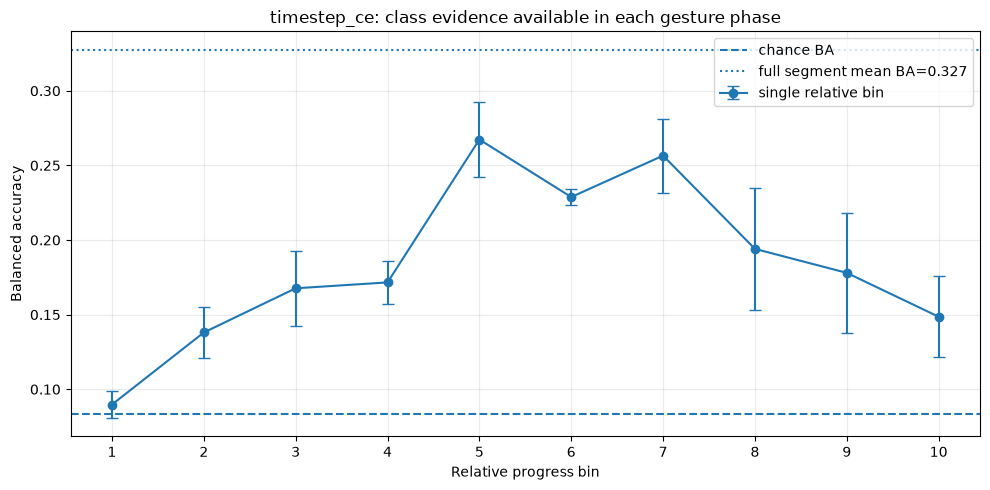

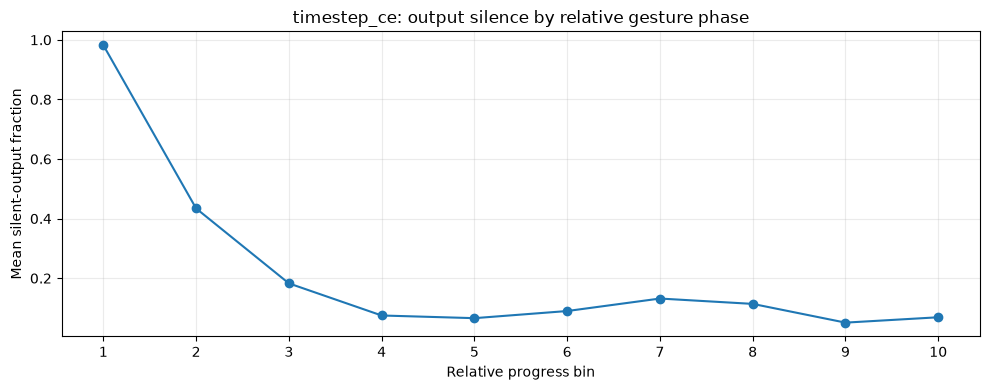

In [17]:
# Mean ± SD across seeds.
profile_summary = (
    bin_profiles.groupby("bin", as_index=False, sort=False)
    .agg(
        mean_ba=("balanced_accuracy", "mean"),
        sd_ba=("balanced_accuracy", "std"),
        mean_silent_fraction=("bin_silent_fraction", "mean"),
    )
)

display(profile_summary)

bin_only = profile_summary[profile_summary["bin"] != "full"].copy()
bin_only["bin_num"] = bin_only["bin"].astype(int)
full_row = profile_summary[profile_summary["bin"] == "full"].iloc[0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    bin_only["bin_num"],
    bin_only["mean_ba"],
    yerr=bin_only["sd_ba"],
    marker="o",
    capsize=4,
    label="single relative bin",
)
ax.axhline(1.0 / NUM_CLASSES, linestyle="--", label="chance BA")
ax.axhline(
    full_row["mean_ba"],
    linestyle=":",
    label=f"full segment mean BA={full_row['mean_ba']:.3f}",
)
ax.set_xticks(range(1, N_RELATIVE_BINS + 1))
ax.set_xlabel("Relative progress bin")
ax.set_ylabel("Balanced accuracy")
ax.set_title("timestep_ce: class evidence available in each gesture phase")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    bin_only["bin_num"],
    bin_only["mean_silent_fraction"],
    marker="o",
)
ax.set_xticks(range(1, N_RELATIVE_BINS + 1))
ax.set_xlabel("Relative progress bin")
ax.set_ylabel("Mean silent-output fraction")
ax.set_title("timestep_ce: output silence by relative gesture phase")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## 14. Diagnostic B — shuffle 200 ms / 500 ms input blocks at test time

The shuffle is applied **inside each sample's valid interval only**. A block is moved as a complete tensor slice, so within-block event timing is unchanged. The same sample-specific shuffle seeds are used for both objectives, making the ablation paired.

Reported quantity:

\[
\Delta BA = BA_{shuffle} - BA_{original}.
\]

Large negative values indicate temporal-order sensitivity. Values near zero indicate that the classifier can largely tolerate the destruction of long-range block order.


In [18]:
def block_steps_from_ms(block_ms):
    return max(1, int(round(block_ms * SAMPLING_RATE_HZ / 1000.0)))


def shuffle_valid_blocks_cpu(
    x_cpu: torch.Tensor,
    lengths_cpu: torch.Tensor,
    sample_ids,
    *,
    block_steps: int,
    shuffle_seed: int,
):
    """Shuffle contiguous valid blocks per sample; preserve samples within each block."""
    x_shuf = x_cpu.clone()

    for i in range(x_cpu.shape[0]):
        length = int(lengths_cpu[i].item())
        if length <= block_steps:
            continue

        blocks = [
            x_cpu[i, start:min(start + block_steps, length)].clone()
            for start in range(0, length, block_steps)
        ]
        if len(blocks) <= 1:
            continue

        local_seed = derive_seed(
            shuffle_seed,
            str(sample_ids[i]),
            "block_order",
            block_steps,
        )
        rng = np.random.default_rng(local_seed)
        order = rng.permutation(len(blocks))
        if np.array_equal(order, np.arange(len(blocks))):
            order = np.roll(order, 1)
        shuffled = torch.cat([blocks[j] for j in order], dim=0)
        if shuffled.shape[0] != length:
            raise RuntimeError("Shuffled valid length changed")

        x_shuf[i, :length] = shuffled
        x_shuf[i, length:] = 0.0

    return x_shuf


@torch.no_grad()
def evaluate_input_block_shuffle(
    model,
    loader,
    *,
    block_ms: float,
    master_seed: int,
    repeat_idx: int,
):
    model.eval()
    block_steps = block_steps_from_ms(block_ms)
    y_true, y_pred = [], []

    shuffle_seed = derive_seed(
        master_seed,
        "test_block_shuffle",
        block_ms,
        repeat_idx,
    )

    for batch in loader:
        # Shuffle on CPU before transfer. valid_mask/length stay unchanged.
        x_cpu = batch["x"]
        lengths_cpu = batch["valid_length"]
        x_cpu = shuffle_valid_blocks_cpu(
            x_cpu,
            lengths_cpu,
            batch["sample_id"],
            block_steps=block_steps,
            shuffle_seed=shuffle_seed,
        )

        x = x_cpu.to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)
        mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
        lengths = lengths_cpu.to(DEVICE, non_blocking=True)

        out = model(x, mask)
        logits = model.native_logits(out, mask, lengths)
        pred = logits.argmax(dim=1)

        y_true.extend(y.cpu().tolist())
        y_pred.extend(pred.cpu().tolist())

    return classification_metrics(y_true, y_pred)


shuffle_rows = []

for master_seed in SEEDS:
    loaders = make_split_loaders(master_seed)

    for objective in OBJECTIVES_TO_RUN:
        run = load_completed_run(master_seed, objective)
        if run is None:
            print(f"Skipping seed={master_seed}, objective={objective}: no checkpoint")
            continue

        model = run["model"]
        original = evaluate_objective_model(model, loaders["test"])
        original_ba = original["balanced_accuracy"]

        shuffle_rows.append({
            "seed": master_seed,
            "objective": objective,
            "condition": "original",
            "block_ms": np.nan,
            "repeat": -1,
            "balanced_accuracy": original_ba,
            "delta_ba_vs_original": 0.0,
        })

        for block_ms in SHUFFLE_BLOCK_MS:
            for repeat_idx in range(N_SHUFFLE_REPEATS):
                metrics = evaluate_input_block_shuffle(
                    model,
                    loaders["test"],
                    block_ms=block_ms,
                    master_seed=master_seed,
                    repeat_idx=repeat_idx,
                )
                ba = metrics["balanced_accuracy"]
                shuffle_rows.append({
                    "seed": master_seed,
                    "objective": objective,
                    "condition": f"shuffle_{int(block_ms)}ms",
                    "block_ms": block_ms,
                    "repeat": repeat_idx,
                    "balanced_accuracy": ba,
                    "delta_ba_vs_original": ba - original_ba,
                })

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

input_shuffle_results = pd.DataFrame(shuffle_rows)
input_shuffle_results.to_csv(
    RESULTS_DIR / "experiment_2_1_1_input_block_shuffle.csv",
    index=False,
)

display(input_shuffle_results)


,seed,objective,condition,block_ms,repeat,balanced_accuracy,delta_ba_vs_original
0,11,timestep_ce,original,NaN,-1,0.328327,0.000000
1,11,timestep_ce,shuffle_200ms,200.0,0,0.297102,-0.031225
2,11,timestep_ce,shuffle_200ms,200.0,1,0.280906,-0.047421
3,11,timestep_ce,shuffle_200ms,200.0,2,0.285882,-0.042445
4,11,timestep_ce,shuffle_200ms,200.0,3,0.254857,-0.073470
5,11,timestep_ce,shuffle_200ms,200.0,4,0.282805,-0.045522
6,11,timestep_ce,shuffle_500ms,500.0,0,0.325139,-0.003188
7,11,timestep_ce,shuffle_500ms,500.0,1,0.285222,-0.043105
8,11,timestep_ce,shuffle_500ms,500.0,2,0.290319,-0.038007
9,11,timestep_ce,shuffle_500ms,500.0,3,0.288807,-0.039520


,objective,condition,mean_ba,sd_ba,mean_delta_ba,sd_delta_ba
0,relative_10bin_ce,original,0.510574,0.069122,0.000000,0.000000
1,relative_10bin_ce,shuffle_200ms,0.145842,0.022838,-0.364732,0.046284
2,relative_10bin_ce,shuffle_500ms,0.169869,0.036234,-0.340704,0.032888
3,timestep_ce,original,0.327489,0.001185,0.000000,0.000000
4,timestep_ce,shuffle_200ms,0.267621,0.017945,-0.059868,0.016761
5,timestep_ce,shuffle_500ms,0.286636,0.015145,-0.040854,0.013960


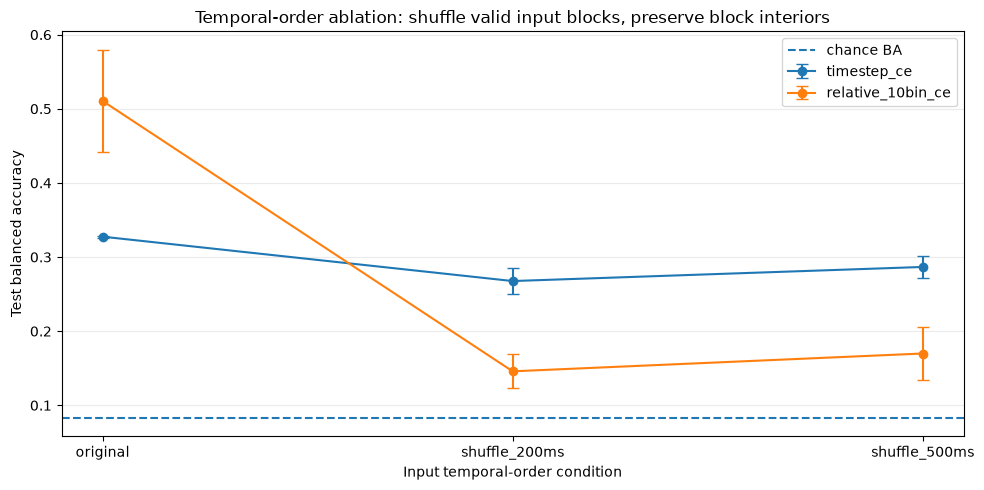

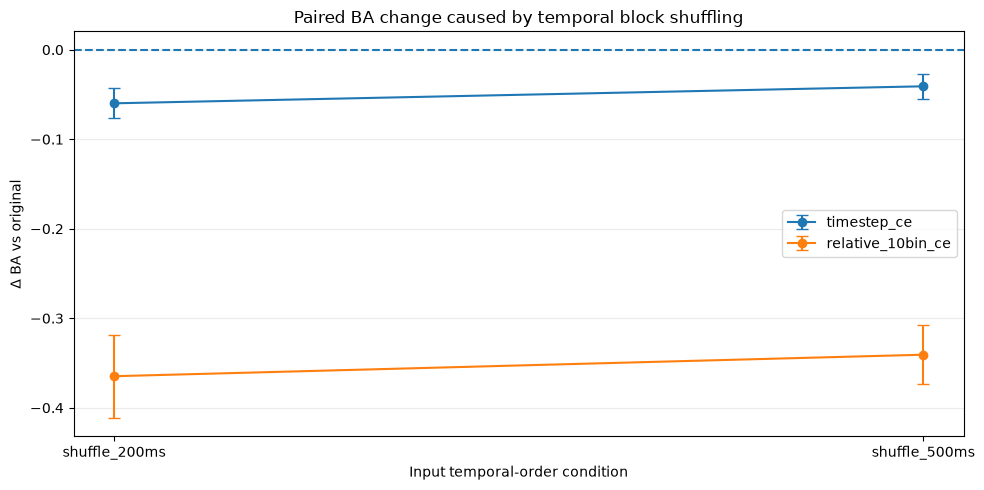

In [19]:
# First average shuffle repeats within seed, then aggregate paired seeds.
input_shuffle_seed_summary = (
    input_shuffle_results
    .groupby(["seed", "objective", "condition"], as_index=False)
    .agg(
        balanced_accuracy=("balanced_accuracy", "mean"),
        delta_ba_vs_original=("delta_ba_vs_original", "mean"),
    )
)

input_shuffle_summary = (
    input_shuffle_seed_summary
    .groupby(["objective", "condition"], as_index=False)
    .agg(
        mean_ba=("balanced_accuracy", "mean"),
        sd_ba=("balanced_accuracy", "std"),
        mean_delta_ba=("delta_ba_vs_original", "mean"),
        sd_delta_ba=("delta_ba_vs_original", "std"),
    )
)

display(input_shuffle_summary)

conditions = ["original"] + [f"shuffle_{int(v)}ms" for v in SHUFFLE_BLOCK_MS]
x = np.arange(len(conditions), dtype=float)

fig, ax = plt.subplots(figsize=(10, 5))
for objective in OBJECTIVES_TO_RUN:
    sdf = input_shuffle_summary[input_shuffle_summary.objective == objective]
    sdf = sdf.set_index("condition").reindex(conditions)
    ax.errorbar(
        x,
        sdf["mean_ba"],
        yerr=sdf["sd_ba"],
        marker="o",
        capsize=4,
        label=objective,
    )

ax.axhline(1.0 / NUM_CLASSES, linestyle="--", label="chance BA")
ax.set_xticks(x, conditions)
ax.set_ylabel("Test balanced accuracy")
ax.set_xlabel("Input temporal-order condition")
ax.set_title("Temporal-order ablation: shuffle valid input blocks, preserve block interiors")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
shuffle_conditions = [c for c in conditions if c != "original"]
x2 = np.arange(len(shuffle_conditions), dtype=float)
for objective in OBJECTIVES_TO_RUN:
    sdf = input_shuffle_summary[
        (input_shuffle_summary.objective == objective)
        & (input_shuffle_summary.condition.isin(shuffle_conditions))
    ].set_index("condition").reindex(shuffle_conditions)
    ax.errorbar(
        x2,
        sdf["mean_delta_ba"],
        yerr=sdf["sd_delta_ba"],
        marker="o",
        capsize=4,
        label=objective,
    )

ax.axhline(0.0, linestyle="--")
ax.set_xticks(x2, shuffle_conditions)
ax.set_ylabel(r"$\Delta$ BA vs original")
ax.set_xlabel("Input temporal-order condition")
ax.set_title("Paired BA change caused by temporal block shuffling")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## 15. Diagnostic C — permute only the 10-bin readout slots of `relative_10bin_ce`

This ablation does **not** change the input and does not rerun the SNN with shuffled input. It computes the ordinary ten output-count bins, then permutes their order before the already-trained linear head.

Therefore the multiset of per-bin spike counts is identical; only temporal-phase identity is destroyed.

Two controls are reported:

- `reverse_10bins`: deterministic reversal of the 10 temporal slots;
- `shuffle_10bins`: sample-specific random permutations, averaged across repeats.


In [20]:
@torch.no_grad()
def collect_relative_bin_features(model, loader):
    """Run the SNN once and cache [N, 10, K] relative-bin count features on CPU."""
    if model.objective != "relative_10bin_ce":
        raise ValueError("Feature collection requires relative_10bin_ce")

    model.eval()
    feature_batches = []
    label_batches = []
    sample_ids = []

    for batch in loader:
        x = batch["x"].to(DEVICE, non_blocking=True)
        mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
        lengths = batch["valid_length"].to(DEVICE, non_blocking=True)

        out = model(x, mask)
        bins = relative_temporal_bin_counts(
            out["output_spikes"], lengths, N_RELATIVE_BINS
        )

        feature_batches.append(bins.cpu())
        label_batches.append(batch["label"].cpu())
        sample_ids.extend([str(v) for v in batch["sample_id"]])

    return (
        torch.cat(feature_batches, dim=0),
        torch.cat(label_batches, dim=0),
        sample_ids,
    )


@torch.no_grad()
def classify_cached_relative_bins(model, bins_cpu, labels_cpu):
    logits = model.readout_head(
        bins_cpu.to(DEVICE).flatten(start_dim=1)
    )
    pred = logits.argmax(dim=1).cpu().tolist()
    return classification_metrics(labels_cpu.tolist(), pred)


def permute_cached_relative_bins(
    bins_cpu,
    sample_ids,
    *,
    mode,
    master_seed,
    repeat_idx=0,
):
    if mode == "original":
        return bins_cpu
    if mode == "reverse":
        return torch.flip(bins_cpu, dims=[1])
    if mode != "shuffle":
        raise ValueError(mode)

    shuffled = bins_cpu.clone()
    for i, sample_id in enumerate(sample_ids):
        local_seed = derive_seed(
            master_seed,
            "relative_readout_bin_shuffle",
            repeat_idx,
            sample_id,
        )
        rng = np.random.default_rng(local_seed)
        perm = torch.as_tensor(
            rng.permutation(N_RELATIVE_BINS),
            dtype=torch.long,
        )
        shuffled[i] = bins_cpu[i, perm]
    return shuffled


readout_shuffle_rows = []

for master_seed in SEEDS:
    run = load_completed_run(master_seed, "relative_10bin_ce")
    if run is None:
        print(f"Skipping seed {master_seed}: relative_10bin_ce checkpoint not found")
        continue

    model = run["model"]
    loaders = make_split_loaders(master_seed)

    # One expensive SNN pass per seed. All permutations below operate on cached tiny features.
    bins_cpu, labels_cpu, sample_ids = collect_relative_bin_features(
        model, loaders["test"]
    )

    original = classify_cached_relative_bins(model, bins_cpu, labels_cpu)
    original_ba = original["balanced_accuracy"]
    readout_shuffle_rows.append({
        "seed": master_seed,
        "condition": "original",
        "repeat": -1,
        "balanced_accuracy": original_ba,
        "delta_ba_vs_original": 0.0,
    })

    reversed_bins = permute_cached_relative_bins(
        bins_cpu,
        sample_ids,
        mode="reverse",
        master_seed=master_seed,
    )
    reverse = classify_cached_relative_bins(model, reversed_bins, labels_cpu)
    readout_shuffle_rows.append({
        "seed": master_seed,
        "condition": "reverse_10bins",
        "repeat": 0,
        "balanced_accuracy": reverse["balanced_accuracy"],
        "delta_ba_vs_original": reverse["balanced_accuracy"] - original_ba,
    })

    for repeat_idx in range(N_READOUT_BIN_SHUFFLE_REPEATS):
        shuffled_bins = permute_cached_relative_bins(
            bins_cpu,
            sample_ids,
            mode="shuffle",
            master_seed=master_seed,
            repeat_idx=repeat_idx,
        )
        metrics = classify_cached_relative_bins(model, shuffled_bins, labels_cpu)
        ba = metrics["balanced_accuracy"]
        readout_shuffle_rows.append({
            "seed": master_seed,
            "condition": "shuffle_10bins",
            "repeat": repeat_idx,
            "balanced_accuracy": ba,
            "delta_ba_vs_original": ba - original_ba,
        })

    del bins_cpu, labels_cpu, model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

readout_shuffle_results = pd.DataFrame(readout_shuffle_rows)
readout_shuffle_results.to_csv(
    RESULTS_DIR / "experiment_2_1_1_relative10bin_readout_order.csv",
    index=False,
)

display(readout_shuffle_results)


,seed,condition,repeat,balanced_accuracy,delta_ba_vs_original
0,11,original,-1,0.559450,0.000000
1,11,reverse_10bins,0,0.163398,-0.396052
2,11,shuffle_10bins,0,0.154754,-0.404696
3,11,shuffle_10bins,1,0.164476,-0.394974
4,11,shuffle_10bins,2,0.205902,-0.353548
5,11,shuffle_10bins,3,0.139898,-0.419552
6,11,shuffle_10bins,4,0.168145,-0.391305
7,11,shuffle_10bins,5,0.195039,-0.364411
8,11,shuffle_10bins,6,0.176318,-0.383132
9,11,shuffle_10bins,7,0.219247,-0.340203


,condition,mean_ba,sd_ba,mean_delta_ba,sd_delta_ba
0,original,0.510574,0.069122,0.000000,0.000000
1,reverse_10bins,0.153195,0.014429,-0.357378,0.054692
2,shuffle_10bins,0.165942,0.020370,-0.344631,0.048752


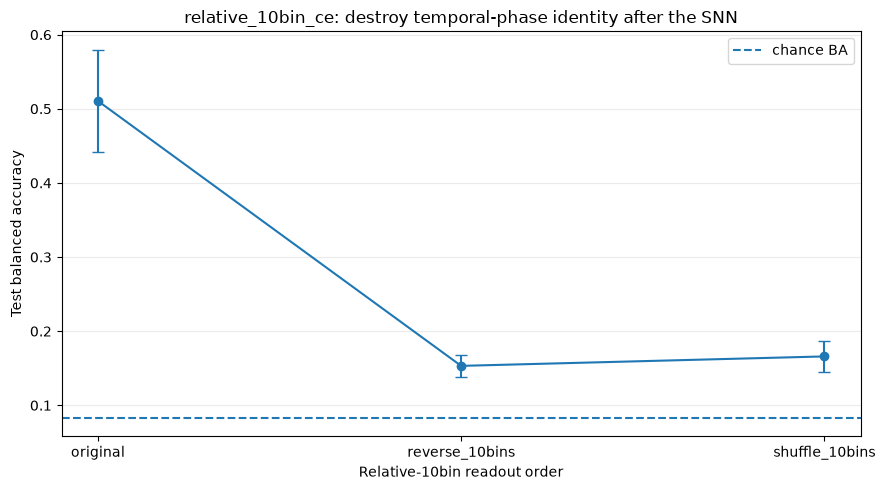

In [21]:
readout_seed_summary = (
    readout_shuffle_results
    .groupby(["seed", "condition"], as_index=False)
    .agg(
        balanced_accuracy=("balanced_accuracy", "mean"),
        delta_ba_vs_original=("delta_ba_vs_original", "mean"),
    )
)

readout_summary = (
    readout_seed_summary.groupby("condition", as_index=False)
    .agg(
        mean_ba=("balanced_accuracy", "mean"),
        sd_ba=("balanced_accuracy", "std"),
        mean_delta_ba=("delta_ba_vs_original", "mean"),
        sd_delta_ba=("delta_ba_vs_original", "std"),
    )
)

display(readout_summary)

conditions = ["original", "reverse_10bins", "shuffle_10bins"]
sdf = readout_summary.set_index("condition").reindex(conditions)
x = np.arange(len(conditions), dtype=float)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    x,
    sdf["mean_ba"],
    yerr=sdf["sd_ba"],
    marker="o",
    capsize=4,
)
ax.axhline(1.0 / NUM_CLASSES, linestyle="--", label="chance BA")
ax.set_xticks(x, conditions)
ax.set_ylabel("Test balanced accuracy")
ax.set_xlabel("Relative-10bin readout order")
ax.set_title("relative_10bin_ce: destroy temporal-phase identity after the SNN")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## 16. Training and model-selection summary

This verifies that the final test diagnostics use the checkpoint selected by validation BA, not by validation loss and not by the final epoch.


,objective,mean_best_epoch,mean_train_ba,sd_train_ba,mean_val_ba,sd_val_ba,mean_test_ba,sd_test_ba,mean_test_macro_f1,mean_output_firing_rate,backbone_params,readout_params,total_params
0,relative_10bin_ce,119.0,0.704665,0.001489,0.413360,0.017865,0.510574,0.069122,0.502228,0.083510,6784,1452,8236
1,timestep_ce,119.0,0.389965,0.020219,0.322421,0.005051,0.327489,0.001185,0.239989,0.139469,6784,0,6784


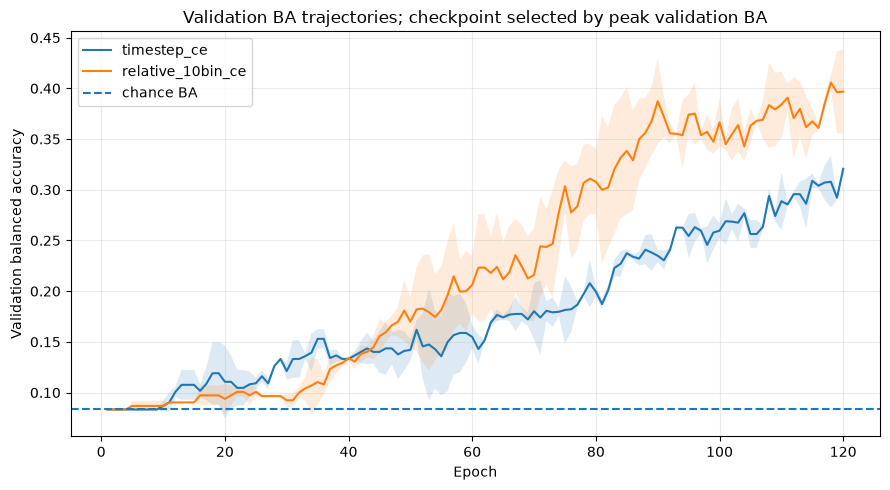

In [22]:
summary = (
    results.groupby("objective", as_index=False)
    .agg(
        mean_best_epoch=("best_epoch_by_val_ba", "mean"),
        mean_train_ba=("train_balanced_accuracy", "mean"),
        sd_train_ba=("train_balanced_accuracy", "std"),
        mean_val_ba=("val_balanced_accuracy", "mean"),
        sd_val_ba=("val_balanced_accuracy", "std"),
        mean_test_ba=("test_balanced_accuracy", "mean"),
        sd_test_ba=("test_balanced_accuracy", "std"),
        mean_test_macro_f1=("test_macro_f1", "mean"),
        mean_output_firing_rate=("test_output_firing_rate", "mean"),
        backbone_params=("backbone_params", "first"),
        readout_params=("readout_params", "first"),
        total_params=("total_params", "first"),
    )
)
summary.to_csv(RESULTS_DIR / "experiment_2_1_1_summary.csv", index=False)
display(summary)

fig, ax = plt.subplots(figsize=(9, 5))
for objective in OBJECTIVES_TO_RUN:
    sdf = histories[histories.objective == objective]
    curve = sdf.groupby("epoch")["val_balanced_accuracy"].agg(["mean", "std"])
    ax.plot(curve.index, curve["mean"], label=objective)
    ax.fill_between(
        curve.index,
        curve["mean"] - curve["std"].fillna(0),
        curve["mean"] + curve["std"].fillna(0),
        alpha=0.15,
    )

ax.axhline(1.0 / NUM_CLASSES, linestyle="--", label="chance BA")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation balanced accuracy")
ax.set_title("Validation BA trajectories; checkpoint selected by peak validation BA")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## 17. Save provenance


In [ ]:
provenance = {
    "experiment_id": EXPERIMENT_ID,
    "parent_experiment": "experiment_2_1_snn_training_objective_ablation",
    "dataset_roots": [str(Path(p).resolve()) for p in DATASET_ROOTS],
    "seeds": list(SEEDS),
    "split_seed": SPLIT_SEED,
    "included_labels": list(INCLUDED_LABELS),
    "class_to_idx": CLASS_TO_IDX,
    "sampling_rate_hz": SAMPLING_RATE_HZ,
    "event_representation": EVENT_REPRESENTATION,
    "event_feature_schema": EVENT_FEATURE_SCHEMA,
    "encoder_spec_sha256": ENCODER_SPEC_SHA256,
    "input_channels": INPUT_CHANNELS,
    "hidden_width": HIDDEN_WIDTH,
    "num_classes": NUM_CLASSES,
    "objectives": list(OBJECTIVES_TO_RUN),
    "objective_definitions": {
        "timestep_ce": "masked per-valid-timestep CE on output spikes",
        "relative_10bin_ce": "relative 10-bin output counts -> Linear -> CE",
    },
    "relative_bin_count": N_RELATIVE_BINS,
    "tau_syn_ms": TAU_SYN_MS,
    "tau_mem_ms": TAU_MEM_MS,
    "alpha": ALPHA,
    "beta": BETA,
    "threshold": THRESHOLD,
    "surrogate_slope": SURROGATE_SLOPE,
    "reset_mechanism": RESET_MECHANISM,
    "snn_linear_bias": False,
    "learn_alpha": False,
    "learn_beta": False,
    "learn_threshold": False,
    "num_epochs": NUM_EPOCHS,
    "early_stopping": False,
    "checkpoint_selection": (
        "maximum validation balanced accuracy after full fixed epoch budget; "
        "tie-break by lower validation loss"
    ),
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "spike_regularization": SPIKE_REGULARIZATION,
    "firing_onset_threshold": FIRING_ONSET_THRESHOLD,
    "input_order_ablation": {
        "block_ms": list(SHUFFLE_BLOCK_MS),
        "shuffle_repeats": N_SHUFFLE_REPEATS,
        "valid_region_only": True,
        "within_block_order_preserved": True,
        "sample_specific_deterministic_permutations": True,
    },
    "timestep_bin_diagnostic": {
        "relative_bins": N_RELATIVE_BINS,
        "prediction": "argmax output-spike count within each bin",
        "reports_silent_fraction": True,
    },
    "relative10bin_readout_order_ablation": {
        "conditions": ["original", "reverse_10bins", "shuffle_10bins"],
        "random_shuffle_repeats": N_READOUT_BIN_SHUFFLE_REPEATS,
        "backbone_output_unchanged": True,
    },
}

with open(
    RESULTS_DIR / "experiment_2_1_1_provenance.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(provenance, f, indent=2, ensure_ascii=False)

print("Saved to:", RESULTS_DIR)


## Decision guide

### For `timestep_ce`

Compare the full-segment BA with the ten single-bin BAs and the input-shuffle BA.

- **Many bins individually strong; 500 ms shuffle nearly unchanged** → current FF SNN is mainly a local-motif detector plus evidence accumulator. Long-range order contributes little.
- **Single bins weak; full segment strong; shuffle nearly unchanged** → weak local evidence is accumulated across time, but exact long-range order still contributes little.
- **500 ms shuffle causes a large drop** → despite no recurrent weights, intrinsic Synaptic-LIF state and sequential transitions make the network materially order-sensitive.
- **200 ms shuffle hurts much more than 500 ms** → investigate carefully; that pattern can indicate sensitivity to artificial block-boundary transitions rather than genuine long-range order.

### For `relative_10bin_ce`

Use both input shuffle and readout-bin permutation.

- **Readout-bin permutation collapses BA** → the linear head explicitly uses temporal-phase identity/order.
- **Input shuffle also collapses BA** → the backbone representation itself is sensitive to temporal sequence, not merely the final temporal slot labels.
- **Readout permutation hurts but input 500 ms shuffle barely hurts** → much of the gain may come from phase-indexed aggregation in the readout rather than long-range memory in the FF SNN backbone.

The key comparison is not merely which objective has higher accuracy. The purpose of Experiment 2.1.1 is to determine **what information each objective is exploiting**.
